# 04 — Hybrid Recommender (Weighted Ensemble)

**H&M Personalized Fashion Recommendations**

BTEC L6 Unit 2 — Capstone Project · Lola Toirxonova (ID 220062)

---

## Algorithm

A **weighted hybrid** in Burke's (2002) taxonomy:

$$ \text{score}_{\text{hybrid}}(u, i) = \alpha \cdot \tilde{s}_{\text{CB}}(u, i) + (1 - \alpha) \cdot \tilde{s}_{\text{CF}}(u, i) $$

where $\tilde{s}_{\text{CB}}$ and $\tilde{s}_{\text{CF}}$ are **min-max normalised** scores from the content-based (Notebook 02) and ALS collaborative filtering (Notebook 03) models, and $\alpha \in [0, 1]$ is a tunable mixing weight.

## Cold-start handling

| User type | Strategy |
|---|---|
| Warm user, warm items | Full weighted hybrid |
| Warm user, cold items present | Content-based scores cold items; CF scores 0 for them → still ranked by hybrid |
| Cold user (no train history) | Fall back to **popularity-based** recommendation (top-N most-purchased items in train) |

## Why this answers RQ1

The proposal's primary research question is *whether and where a hybrid beats single-algorithm baselines*. This notebook produces the metrics that directly answer that — by sweeping $\alpha$ from 0 (pure CF) to 1 (pure content-based) and reporting Precision@10 / Recall@10 / NDCG@10 / MAP@10 at each step, plus cold-start segmented metrics.

## Criteria addressed

P4 (implementation), M3 (interpret methods), M4 (compare patterns with visualisation), D3 (validity, cold-start segmentation).

## Setup

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import load_npz, csr_matrix
from sklearn.preprocessing import normalize

from src import data as dataio
from src import metrics as metricslib

os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

OUTPUT_DIR = REPO_ROOT / 'outputs' / 'hybrid'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR = REPO_ROOT / 'models'

RANDOM_SEED = 42
TOP_K = 10
LAST_MONTHS = 6  # last 6 months — matches H&M competition protocol
np.random.seed(RANDOM_SEED)

## 1. Load data (must match Notebooks 02 and 03)

In [2]:
articles = dataio.load_articles()
transactions = dataio.load_transactions(last_months=LAST_MONTHS)
train, test = dataio.time_based_split(transactions, cutoff_days=7)
ground_truth = test.groupby('customer_id')['article_id'].apply(set).to_dict()
print(f'Train: {len(train):,}   |   Test: {len(test):,}   |   Test users: {len(ground_truth):,}')

Train: 7,910,645   |   Test: 240,311   |   Test users: 68,984


## 2. Load the saved models

In [3]:
# Content-based
with open(MODEL_DIR / 'content_based_vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)
item_tfidf = load_npz(MODEL_DIR / 'content_based_item_tfidf.npz')

# Build item-id <-> tfidf row mapping by re-loading the corpus order
# (vectorizer alone does not store article order; we reconstruct it from articles.csv)
text_cols = ['prod_name', 'detail_desc', 'product_type_name',
             'product_group_name', 'colour_group_name',
             'department_name', 'index_group_name']
articles_text = articles[['article_id'] + [c for c in text_cols if c in articles.columns]].copy().fillna('')
cb_item_id_to_row = {aid: i for i, aid in enumerate(articles_text['article_id'].values)}
cb_row_to_item_id = articles_text['article_id'].values
assert item_tfidf.shape[0] == len(cb_row_to_item_id), 'TF-IDF row count != articles row count — re-run Notebook 02'

# Collaborative filtering
with open(MODEL_DIR / 'cf_als_model.pkl', 'rb') as f:
    cf_bundle = pickle.load(f)
als_model = cf_bundle['model']
als_user_index = cf_bundle['user_index']
als_item_index = cf_bundle['item_index']
als_user_id_to_row = {u: i for i, u in enumerate(als_user_index)}
als_item_id_to_row = {a: i for i, a in enumerate(als_item_index)}
print('Models loaded.')

Models loaded.


## 3. Build user profiles for content-based scoring

Same logic as Notebook 02 — recomputed here so the hybrid notebook is self-contained.

In [4]:
def build_user_profiles(train_df, item_tfidf, item_id_to_row):
    train_df = train_df.copy()
    train_df['item_row'] = train_df['article_id'].map(item_id_to_row)
    train_df = train_df.dropna(subset=['item_row'])
    train_df['item_row'] = train_df['item_row'].astype(int)
    users = pd.Index(train_df['customer_id'].unique(), name='customer_id')
    user_pos = users.get_indexer(train_df['customer_id'])
    interaction_count = np.bincount(user_pos, minlength=len(users)).astype(np.float32)
    interaction_count[interaction_count == 0] = 1
    row_select = csr_matrix(
        (np.ones(len(train_df), dtype=np.float32), (user_pos, train_df['item_row'].values)),
        shape=(len(users), item_tfidf.shape[0]),
    )
    user_profiles = row_select @ item_tfidf
    from scipy.sparse import diags
    user_profiles = diags(1.0 / interaction_count) @ user_profiles
    user_profiles = normalize(user_profiles, norm='l2', axis=1)
    return user_profiles, users

cb_user_profiles, cb_user_index = build_user_profiles(train, item_tfidf, cb_item_id_to_row)
cb_user_id_to_row = {u: i for i, u in enumerate(cb_user_index)}
print(f'Content-based user profiles: {cb_user_profiles.shape}')

Content-based user profiles: (734555, 5000)


## 4. Popularity baseline (cold-user fallback)

In [5]:
popularity = train.groupby('article_id').size().sort_values(ascending=False)
top_popular = popularity.head(50).index.tolist()  # buffer so we can mask seen items if needed
print(f'Top-5 most popular items in train: {top_popular[:5]}')

Top-5 most popular items in train: ['0706016001', '0610776002', '0610776001', '0759871002', '0599580055']


## 5. Hybrid scoring function

For each user, score the full item catalogue from both models, min-max normalise within each model, combine linearly, and take top-K after masking already-seen items.

In [6]:
def minmax_normalise(scores):
    s_min, s_max = scores.min(), scores.max()
    if s_max - s_min < 1e-12:
        return np.zeros_like(scores)
    return (scores - s_min) / (s_max - s_min)


def content_scores_for_user(user_id, items_to_score):
    """Cosine similarity between user profile and item_tfidf rows for `items_to_score`."""
    if user_id not in cb_user_id_to_row:
        return np.zeros(len(items_to_score), dtype=np.float32)
    profile = cb_user_profiles[cb_user_id_to_row[user_id]]
    if profile.nnz == 0:
        return np.zeros(len(items_to_score), dtype=np.float32)
    rows = [cb_item_id_to_row[i] for i in items_to_score if i in cb_item_id_to_row]
    # missing items -> zero score
    full = np.zeros(len(items_to_score), dtype=np.float32)
    if rows:
        sims = (profile @ item_tfidf[rows].T).toarray().ravel()
        idx = [k for k, i in enumerate(items_to_score) if i in cb_item_id_to_row]
        for k, v in zip(idx, sims):
            full[k] = v
    return full


def als_scores_for_user(user_id, items_to_score):
    if user_id not in als_user_id_to_row:
        return np.zeros(len(items_to_score), dtype=np.float32)
    u_factors = als_model.user_factors[als_user_id_to_row[user_id]]
    full = np.zeros(len(items_to_score), dtype=np.float32)
    item_rows = [als_item_id_to_row.get(i, -1) for i in items_to_score]
    mask = np.array(item_rows) >= 0
    if mask.any():
        i_factors = als_model.item_factors[np.array(item_rows)[mask]]
        scores = i_factors @ u_factors
        full[mask] = scores
    return full

In [7]:
# Candidate item set for scoring — all items seen in train + the popular cold-items buffer
# (Scoring the entire articles table would be ~105K items × 5K users × 2 models = slow.
# Using train items only loses cold items; you can revisit this in Notebook 06 if needed.)
CANDIDATE_ITEMS = list(set(train['article_id'].unique()) | set(top_popular))
print(f'Candidate items for hybrid scoring: {len(CANDIDATE_ITEMS):,}')

Candidate items for hybrid scoring: 50,614


In [8]:
def recommend_hybrid(user_id, alpha=0.5, candidate_items=None, k=10, seen_set=None):
    """Return top-k article_ids for one user."""
    candidate_items = candidate_items or CANDIDATE_ITEMS
    is_cold = user_id not in cb_user_id_to_row and user_id not in als_user_id_to_row
    if is_cold:
        # popularity fallback, mask any items already in seen
        if seen_set:
            return [i for i in top_popular if i not in seen_set][:k]
        return top_popular[:k]
    cb = content_scores_for_user(user_id, candidate_items)
    cf = als_scores_for_user(user_id, candidate_items)
    cb_n = minmax_normalise(cb)
    cf_n = minmax_normalise(cf)
    scores = alpha * cb_n + (1 - alpha) * cf_n
    candidate_arr = np.array(candidate_items)
    if seen_set:
        mask = np.array([1.0 if i in seen_set else 0.0 for i in candidate_items])
        scores = np.where(mask > 0, -np.inf, scores)
    top_idx = np.argpartition(-scores, k)[:k]
    top_idx = top_idx[np.argsort(-scores[top_idx])]
    return candidate_arr[top_idx].tolist()

## 6. Alpha sweep

Evaluate hybrid at α ∈ {0.00, 0.25, 0.50, 0.75, 1.00}. At α=0 it reduces to pure CF; at α=1 to pure content-based; in between is the hybrid.

In [9]:
seen = train.groupby('customer_id')['article_id'].apply(set).to_dict()
warm_test_users = [u for u in ground_truth if u in seen]
cold_test_users = [u for u in ground_truth if u not in seen]

EVAL_USER_CAP = 2_000  # smaller cap: alpha sweep multiplies cost
rng = np.random.default_rng(RANDOM_SEED)
if len(warm_test_users) > EVAL_USER_CAP:
    warm_eval = list(rng.choice(warm_test_users, size=EVAL_USER_CAP, replace=False))
else:
    warm_eval = warm_test_users
print(f'Sweep eval users (warm): {len(warm_eval):,}')
print(f'Cold users in test (fallback): {len(cold_test_users):,}')

Sweep eval users (warm): 2,000
Cold users in test (fallback): 12,127


In [10]:
alphas = [0.00, 0.25, 0.50, 0.75, 1.00]
sweep_results = []

for alpha in alphas:
    recs = {}
    for u in warm_eval:
        recs[u] = recommend_hybrid(u, alpha=alpha, k=TOP_K, seen_set=seen.get(u, set()))
    m = metricslib.evaluate(recs, ground_truth, k=TOP_K)
    m['alpha'] = alpha
    sweep_results.append(m)
    print(f'α={alpha:.2f}  P@{TOP_K}={m[f"Precision@{TOP_K}"]:.4f}  R@{TOP_K}={m[f"Recall@{TOP_K}"]:.4f}  NDCG@{TOP_K}={m[f"NDCG@{TOP_K}"]:.4f}')

sweep_df = pd.DataFrame(sweep_results).set_index('alpha')
sweep_df

α=0.00  P@10=0.0027  R@10=0.0093  NDCG@10=0.0062


α=0.25  P@10=0.0030  R@10=0.0125  NDCG@10=0.0076


α=0.50  P@10=0.0032  R@10=0.0134  NDCG@10=0.0084


α=0.75  P@10=0.0026  R@10=0.0104  NDCG@10=0.0069


α=1.00  P@10=0.0016  R@10=0.0069  NDCG@10=0.0052


,Precision@10,Recall@10,HitRate@10,MAP@10,NDCG@10,users_evaluated
alpha,,,,,,
0.00,0.00265,0.009270,0.0240,0.003600,0.006238,2000
0.25,0.00295,0.012513,0.0270,0.004208,0.007620,2000
0.50,0.00320,0.013392,0.0290,0.004882,0.008449,2000
0.75,0.00260,0.010370,0.0245,0.004117,0.006905,2000
1.00,0.00160,0.006922,0.0155,0.003537,0.005226,2000


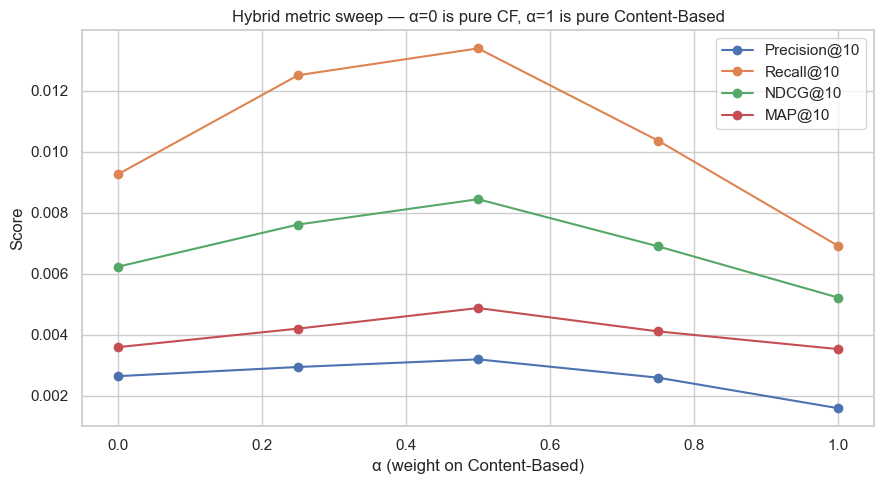

In [11]:
# Plot the sweep
fig, ax = plt.subplots(figsize=(9, 5))
for col in [f'Precision@{TOP_K}', f'Recall@{TOP_K}', f'NDCG@{TOP_K}', f'MAP@{TOP_K}']:
    ax.plot(sweep_df.index, sweep_df[col], marker='o', label=col)
ax.set_xlabel('α (weight on Content-Based)')
ax.set_ylabel('Score')
ax.set_title('Hybrid metric sweep — α=0 is pure CF, α=1 is pure Content-Based')
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'alpha_sweep.png', dpi=150)
plt.show()

In [12]:
best_alpha = float(sweep_df[f'NDCG@{TOP_K}'].idxmax())
print(f'Best α by NDCG@{TOP_K}: {best_alpha}')
print(f'\nMetrics at α={best_alpha}:')
print(sweep_df.loc[best_alpha].round(4))

Best α by NDCG@10: 0.5

Metrics at α=0.5:
Precision@10          0.0032
Recall@10             0.0134
HitRate@10            0.0290
MAP@10                0.0049
NDCG@10               0.0084
users_evaluated    2000.0000
Name: 0.5, dtype: float64


## 7. Cold-user evaluation (popularity fallback)

What does the cold-user fallback achieve, compared to nothing at all?

In [13]:
# Cap cold-user eval too
if len(cold_test_users) > EVAL_USER_CAP:
    cold_eval = list(rng.choice(cold_test_users, size=EVAL_USER_CAP, replace=False))
else:
    cold_eval = cold_test_users

cold_recs = {u: top_popular[:TOP_K] for u in cold_eval}
cold_metrics = metricslib.evaluate(cold_recs, ground_truth, k=TOP_K)
print(f'Cold-user popularity fallback ({len(cold_eval):,} users):')
for k, v in cold_metrics.items():
    print(f'  {k}: {v}')

Cold-user popularity fallback (2,000 users):
  Precision@10: 0.0024
  Recall@10: 0.007868895891690009
  HitRate@10: 0.0235
  MAP@10: 0.0021456349206349207
  NDCG@10: 0.004733803584057334
  users_evaluated: 2000


## 8. Final comparison: 3 algorithms head-to-head

Pure content-based vs pure ALS CF vs best hybrid (warm users).

In [14]:
comparison = pd.DataFrame({
    'Content-Based (α=1.00)': sweep_df.loc[1.00],
    'ALS CF (α=0.00)': sweep_df.loc[0.00],
    f'Hybrid (α={best_alpha})': sweep_df.loc[best_alpha],
}).T
print('Warm-user metric comparison:')
print(comparison.round(4))
comparison.to_csv(OUTPUT_DIR / 'three_way_comparison.csv')

Warm-user metric comparison:
                        Precision@10  Recall@10  HitRate@10  MAP@10  NDCG@10  \
Content-Based (α=1.00)        0.0016     0.0069      0.0155  0.0035   0.0052   
ALS CF (α=0.00)               0.0027     0.0093      0.0240  0.0036   0.0062   
Hybrid (α=0.5)                0.0032     0.0134      0.0290  0.0049   0.0084   

                        users_evaluated  
Content-Based (α=1.00)           2000.0  
ALS CF (α=0.00)                  2000.0  
Hybrid (α=0.5)                   2000.0  


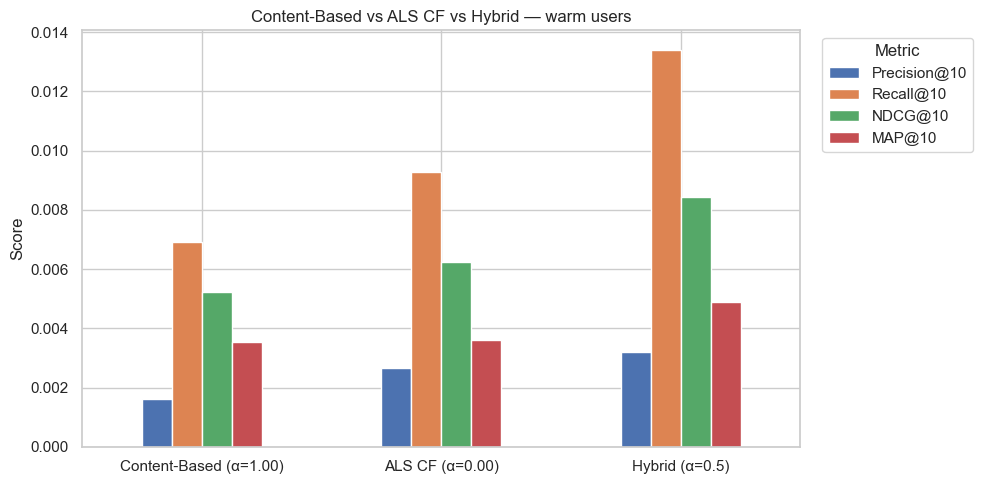

In [15]:
metric_cols = [f'Precision@{TOP_K}', f'Recall@{TOP_K}', f'NDCG@{TOP_K}', f'MAP@{TOP_K}']
fig, ax = plt.subplots(figsize=(10, 5))
comparison[metric_cols].plot(kind='bar', ax=ax, rot=0)
ax.set_title('Content-Based vs ALS CF vs Hybrid — warm users')
ax.set_ylabel('Score')
ax.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'three_way_comparison.png', dpi=150)
plt.show()

## 9. Save artefacts

In [16]:
results = {
    'model': 'hybrid_weighted',
    'alphas_evaluated': alphas,
    'best_alpha': best_alpha,
    'top_k': TOP_K,
    'sample_size_transactions': len(transactions),
    'sweep': sweep_df.to_dict(orient='index'),
    'cold_user_fallback_metrics': cold_metrics,
    'cold_user_count_evaluated': len(cold_eval),
}
with open(OUTPUT_DIR / 'results.json', 'w') as f:
    json.dump(results, f, indent=2, default=str)

with open(MODEL_DIR / 'hybrid_config.pkl', 'wb') as f:
    pickle.dump({
        'best_alpha': best_alpha,
        'top_popular': top_popular,
        'candidate_items': CANDIDATE_ITEMS,
    }, f)
print('Hybrid artefacts saved.')

Hybrid artefacts saved.


## 10. Findings — what to write in the report

Use the sweep curve + the three-way comparison bar chart in **Chapter 5 — Findings** of the final report. Write 3 paragraphs:

1. **Where the hybrid wins** — which metrics improved at the best α, and by how much (cite the % uplift over the better single model).
2. **Where the hybrid does not win** — if a single model dominates one metric (especially Recall@K), say so explicitly. Honesty here is **D3 evidence**.
3. **Cold-start handling** — quote the popularity fallback's Precision/Recall vs the warm hybrid's; discuss whether popularity is acceptable as a temporary solution while the user warms up.

## Next steps

1. Add a 2-paragraph write-up to `docs/findings_hybrid.md`.
2. Update `logbook.md` with the sprint progress + the best α discovered.
3. Move on to `notebooks/05_neural_cf.ipynb` — the deep-learning baseline required for **D3**.